In [1]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from dataclasses import dataclass, field
from typing import Optional, Tuple, List, Dict, Any
import time
from PIL import Image
import warnings

warnings.filterwarnings('ignore')
# Ensure plots render interactively in the notebook
%matplotlib inline

1. Theoretical Foundation of 2D Gabor FiltersA 2D Gabor filter acts as a localized bandpass filter. It is mathematically defined as a complex sinusoidal carrier wave modulated by a two-dimensional Gaussian envelope. This structural confinement prevents the infinite spatial extent inherent to global Fourier transforms, allowing for the precise spatial localization of frequency components.The complex spatial domain representation is given by:$$g(x, y) = \frac{1}{2\pi \sigma_x \sigma_y} e^{-\frac{1}{2} \left( \frac{x'^2}{\sigma_x^2} + \frac{y'^2}{\sigma_y^2} \right)} e^{i 2\pi f x'}$$Where $x'$ and $y'$ represent spatial coordinates rotated by an orientation angle $\theta$:$$x' = x \cos(\theta) + y \sin(\theta)$$
$$y' = -x \sin(\theta) + y \cos(\theta)$$

To facilitate computation in digital environments without native complex-tensor architectures, Euler's formula ($e^{i\omega} = \cos\omega + i\sin\omega$) is utilized to explicitly bifurcate the kernel into dual components:Real Kernel: An even-symmetric field defined by the Gaussian multiplied by $\cos(2\pi f x')$.Imaginary Kernel: An odd-symmetric field defined by the Gaussian multiplied by $\sin(2\pi f x')$.A direct current (DC) correction is typically applied to the real kernel to ensure a zero-sum integral, preventing the filter from responding to areas of uniform flat intensity.

We take our bank of filters (different frequencies, different angles) and slide them across the image.Mathematically, this is a convolution, denoted by $*$. For a given image $I(x,y)$ and kernel $g(x,y)$, the response $R$ is:$$R(x,y) = (I * g)(x,y)$$Because sliding large grids over each other is computationally brutal, scipy flips this into the frequency domain using the Fast Fourier Transform (FFT), multiplies them, and flips back to the spatial domain ($O(N \log N)$ complexity).For every pixel, this convolution spits out two values: the real response ($R_{real}$) and the imaginary response ($R_{imag}$). From these dual channels, we reconstruct the physical properties of the local wave:
Magnitude: $$A = \sqrt{R_{real}^2 + R_{imag}^2}$$ How strong is this specific pattern?

Phase: $$\phi = \arctan\left(\frac{R_{imag}}{R_{real}}\right)$$ Where are we in the cycle of the wave?

In [2]:
@dataclass
class GaborParams2D:
    frequencies: List[float]          # Spatial frequencies (cycles/pixel)
    thetas: List[float]               # Orientations in radians
    sigmas_x: List[float]             # Gaussian width along x-axis
    sigmas_y: List[float]             # Gaussian width along y-axis
    n_stds: float = 3.0               # Kernel size = 2 * n_stds * max_sigma + 1

@dataclass
class PipelineConfig:
    compute_statistics: bool = True
    verbose: bool = True

@dataclass
class AnalysisResult2D:
    spatial_shape: Tuple[int, int]
    frequencies: np.ndarray
    thetas: np.ndarray
    responses_real: np.ndarray        # Shape: (n_freq, n_theta, H, W)
    responses_imag: np.ndarray
    responses_magnitude: np.ndarray 
    responses_phase: np.ndarray
    energy_map: np.ndarray            
    dominant_orientation: np.ndarray  
    dominant_frequency: np.ndarray    
    processing_time_s: float = 0.0

class GaborKernel2D:
    @staticmethod
    def build(frequency: float, theta: float,
              sigma_x: float, sigma_y: float,
              n_stds: float = 3.0) -> Tuple[np.ndarray, np.ndarray]:
        
        max_sigma = max(sigma_x, sigma_y)
        half = int(np.ceil(n_stds * max_sigma))
        size = 2 * half + 1

        y_grid, x_grid = np.mgrid[-half:half + 1, -half:half + 1].astype(np.float64)

        cos_t, sin_t = np.cos(theta), np.sin(theta)
        x_rot = x_grid * cos_t + y_grid * sin_t
        y_rot = -x_grid * sin_t + y_grid * cos_t

        gaussian = np.exp(-0.5 * ((x_rot / sigma_x) ** 2 + (y_rot / sigma_y) ** 2))
        gaussian /= (gaussian.sum() + 1e-12)

        omega = 2.0 * np.pi * frequency
        real_kernel = gaussian * np.cos(omega * x_rot)
        imag_kernel = gaussian * np.sin(omega * x_rot)

        # DC correction
        real_kernel -= real_kernel.mean()

        return real_kernel, imag_kernel

In [3]:
class GaborPipeline2D:
    def __init__(self, params: GaborParams2D, config: PipelineConfig):
        self.params = params
        self.config = config
        self._kernels = []

    def _validate_image(self, img: np.ndarray) -> np.ndarray:
        img = np.asarray(img, dtype=np.float64)
        if img.ndim == 3:
            if img.shape == 3:
                img = 0.2126 * img[..., 0] + 0.7152 * img[..., 1] + 0.0722 * img[..., 2]
            elif img.shape == 1:
                img = img[..., 0]
        # Normalize to
        lo, hi = img.min(), img.max()
        if hi > lo:
            img = (img - lo) / (hi - lo)
        return img

    def _build_filterbank(self):
        self._kernels = []
        for fi, freq in enumerate(self.params.frequencies):
            row = []
            sx = self.params.sigmas_x[fi % len(self.params.sigmas_x)]
            sy = self.params.sigmas_y[fi % len(self.params.sigmas_y)]
            for theta in self.params.thetas:
                rk, ik = GaborKernel2D.build(freq, theta, sx, sy, self.params.n_stds)
                row.append((rk, ik))
            self._kernels.append(row)

    def _convolve_image(self, img: np.ndarray):
        nf = len(self.params.frequencies)
        nt = len(self.params.thetas)
        H, W = img.shape
        
        real_out = np.zeros((nf, nt, H, W), dtype=np.float32)
        imag_out = np.zeros((nf, nt, H, W), dtype=np.float32)
        mag = np.zeros((nf, nt, H, W), dtype=np.float32)
        phs = np.zeros((nf, nt, H, W), dtype=np.float32)

        for fi in range(nf):
            for ti in range(nt):
                rk, ik = self._kernels[fi][ti]
                real_r = signal.fftconvolve(img, rk, mode='same')
                imag_r = signal.fftconvolve(img, ik, mode='same')
                
                real_out[fi, ti] = real_r
                imag_out[fi, ti] = imag_r
                mag[fi, ti] = np.sqrt(real_r ** 2 + imag_r ** 2)
                phs[fi, ti] = np.arctan2(imag_r, real_r)

        return real_out, imag_out, mag, phs

    def analyze(self, img: np.ndarray, label: str = '') -> AnalysisResult2D:
        t0 = time.time()
        img = self._validate_image(img)
        H, W = img.shape

        self._build_filterbank()
        real_out, imag_out, mag, phs = self._convolve_image(img)
        
        energy = np.sum(mag ** 2, axis=(0, 1))
        
        mag_per_theta = mag.sum(axis=0)
        dom_theta = np.array(self.params.thetas)[np.argmax(mag_per_theta, axis=0)]
        
        mag_per_freq = mag.sum(axis=1)
        dom_freq = np.array(self.params.frequencies)[np.argmax(mag_per_freq, axis=0)]

        if self.config.verbose:
            print(f"[{label}] Processed {H}x{W} in {time.time() - t0:.2f}s")

        return AnalysisResult2D(
            spatial_shape=(H, W),
            frequencies=np.array(self.params.frequencies),
            thetas=np.array(self.params.thetas),
            responses_real=real_out,
            responses_imag=imag_out,
            responses_magnitude=mag,
            responses_phase=phs,
            energy_map=energy,
            dominant_orientation=dom_theta,
            dominant_frequency=dom_freq,
        )

Filterbank Construction and The Filter SuiteComprehensive spatial analysis cannot be achieved with a singular kernel; it requires a coordinated suite, or filterbank—spanning multiple spatial frequencies ($f$) and orientations ($\theta$).Target frequencies are typically distributed according to a roughly logarithmic or geometric progression. This design adheres to the $1/f$ amplitude statistics characteristic of natural and biological structures, providing dense resolution at lower frequencies (for macroscopic architectural features) and sparse resolution at higher frequencies approaching the Nyquist limit (for micro-textures and sharp boundaries).

In [4]:
def get_bscan(tomogram: np.ndarray, bscan_idx: int = None):
    """
    Retrieves a B-scan (cross-section) from an OCT tomogram.
    """
    # Handle Complex Field Data -> Get Magnitude
    if np.iscomplexobj(tomogram):
        mag = np.abs(tomogram)
    elif tomogram.ndim == 4 and tomogram.shape[-1] == 2:
        # Format used in your codebase: [Depth, X, Y, Channels (Re, Im)]
        mag = np.sqrt(tomogram[..., 0]**2 + tomogram[..., 1]**2)
    else:
        mag = tomogram

    # Logarithmic Scaling (Decibel scale)
    # Add a small epsilon (1e-8) to prevent log10(0) warnings
    db_tomogram = 20 * np.log10(mag + 1e-8)

    # Create the views
    # Determine the middle slice for the B-scan if not specified
    if bscan_idx is None:
        bscan_idx = db_tomogram.shape[2] // 2 

    # B-scan: Depth (Z) vs Fast Axis (X) at a specific Slow Axis (Y) index
    b_scan = db_tomogram[:, :, bscan_idx]

    return b_scan

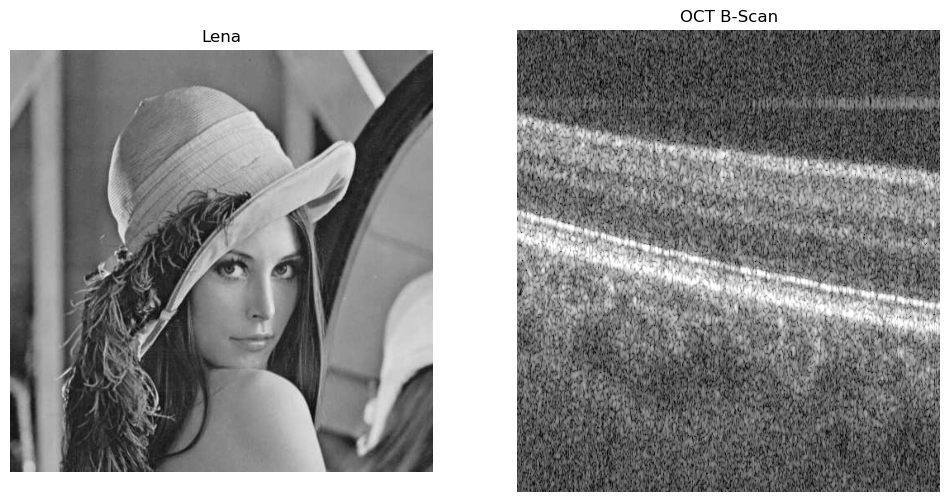

In [10]:
# 1. Load Lena
lena = np.array(Image.open("C:\\Users\\jcosp\\dev\\dloct-thesis\\data\\Original_lena512.jpg"))

# 2. Load OCT Tomogram
# (Assuming get_bscan is defined. If not, replace with your actual function logic)
oct_tom = np.load("C:\\Users\\jcosp\\dev\\dloct-thesis\\data\\train\\phase\\S.Eye2A.npy")
bscan = get_bscan(oct_tom, bscan_idx=40)

# Calculate percentiles for display clipping
vmin = np.percentile(bscan, 1)    # Bottom 1% (Noise floor)
vmax = np.percentile(bscan, 99.5) # Top 0.5% (Specular reflections)

# Verify loading visually
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(lena, cmap='gray')
ax1.set_title("Lena")
ax1.axis('off')

ax2.imshow(bscan, cmap='gray', aspect='auto', vmin=vmin, vmax=vmax)
ax2.set_title("OCT B-Scan")
ax2.axis('off')
plt.show()

1. Integrated Energy MapComputation: The total structural signal strength at each spatial coordinate. It is computed by squaring the magnitude (to obtain energy) and integrating this value across the entire filterbank (all frequencies and all orientations).Equation:$$E(x,y) = \sum_{f} \sum_{\theta} \left( A_{f, \theta}(x,y) \right)^2$$Output: A 2D scalar field where intensity directly correlates to the total localized structural complexity or contrast, independent of its specific direction or scale.2. Dominant Orientation MapComputation: The primary directional alignment of the local geometry. It is computed by first marginalizing (summing) the magnitude responses across all spatial frequencies to obtain an orientation-dependent vector, and then extracting the argument of the maximum (argmax) along the orientation axis.Equation:$$\theta_{\text{dom}}(x,y) = \arg\max_{\theta} \left( \sum_{f} A_{f, \theta}(x,y) \right)$$Output: A 2D discrete field where each pixel is assigned the specific angle $\theta$ (from the predefined filterbank parameters) that yielded the maximum cumulative resonant response.3. Dominant Frequency MapComputation: The primary spatial scale of the local geometry. It is computed by first marginalizing the magnitude responses across all orientations to obtain a frequency-dependent vector, and then extracting the argmax along the frequency axis.Equation:$$f_{\text{dom}}(x,y) = \arg\max_{f} \left( \sum_{\theta} A_{f, \theta}(x,y) \right)$$Output: A 2D discrete field where each pixel is assigned the specific spatial frequency $f$ that yielded the maximum cumulative response, mathematically differentiating macroscopic boundaries from microscopic textures.

[Lena] Processed 512x512 in 2.39s


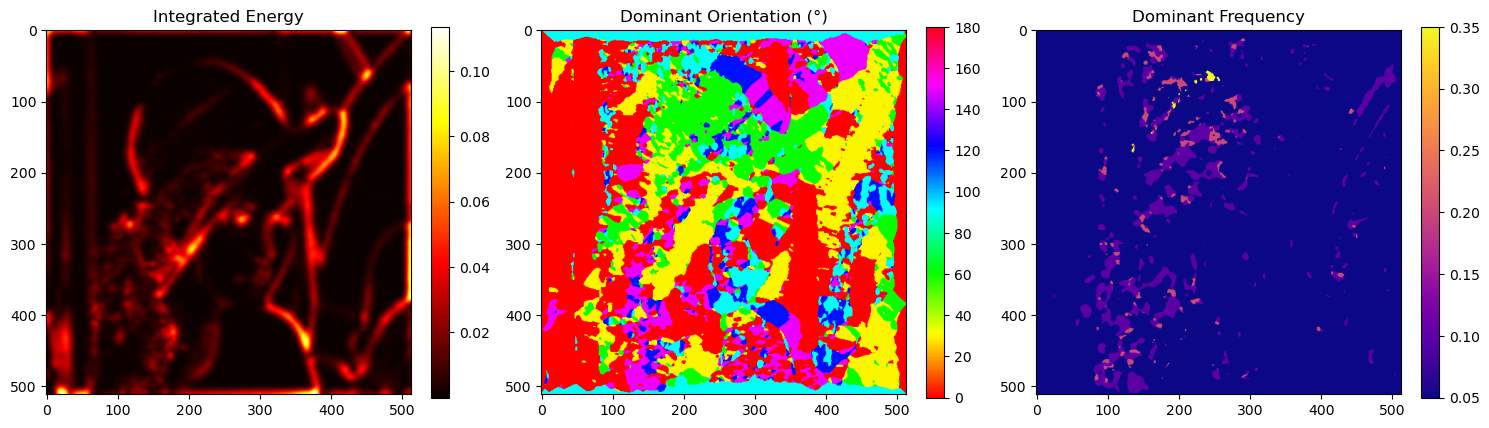

In [24]:

params_2d = GaborParams2D(
    frequencies=[0.05, 0.10, 0.20, 0.35, 0.5, 0.6],
    thetas=[k * np.pi / 6 for k in range(6)], # 0 to 150 degrees
    sigmas_x=[8.0, 6.0, 4.0, 3.0],
    sigmas_y=[4.0, 3.0, 2.0, 1.5]
)
config = PipelineConfig(verbose=True)
pipeline = GaborPipeline2D(params_2d, config)

result_lena = pipeline.analyze(lena, label="Lena")

# Plot Energy and Dominant Features
# Unpack the axes directly into ax1, ax2, and ax3 so we don't deal with arrays
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Energy
im0 = ax1.imshow(result_lena.energy_map, cmap='hot')
ax1.set_title('Integrated Energy')
plt.colorbar(im0, ax=ax1, fraction=0.046)

# Plot 2: Orientation
im1 = ax2.imshow(np.degrees(result_lena.dominant_orientation), cmap='hsv', vmin=0, vmax=180)
ax2.set_title('Dominant Orientation (°)')
plt.colorbar(im1, ax=ax2, fraction=0.046)

# Plot 3: Frequency
im2 = ax3.imshow(result_lena.dominant_frequency, cmap='plasma')
ax3.set_title('Dominant Frequency')
plt.colorbar(im2, ax=ax3, fraction=0.046)

plt.tight_layout()
plt.show()

[OCT B-Scan] Processed 512x512 in 7.00s


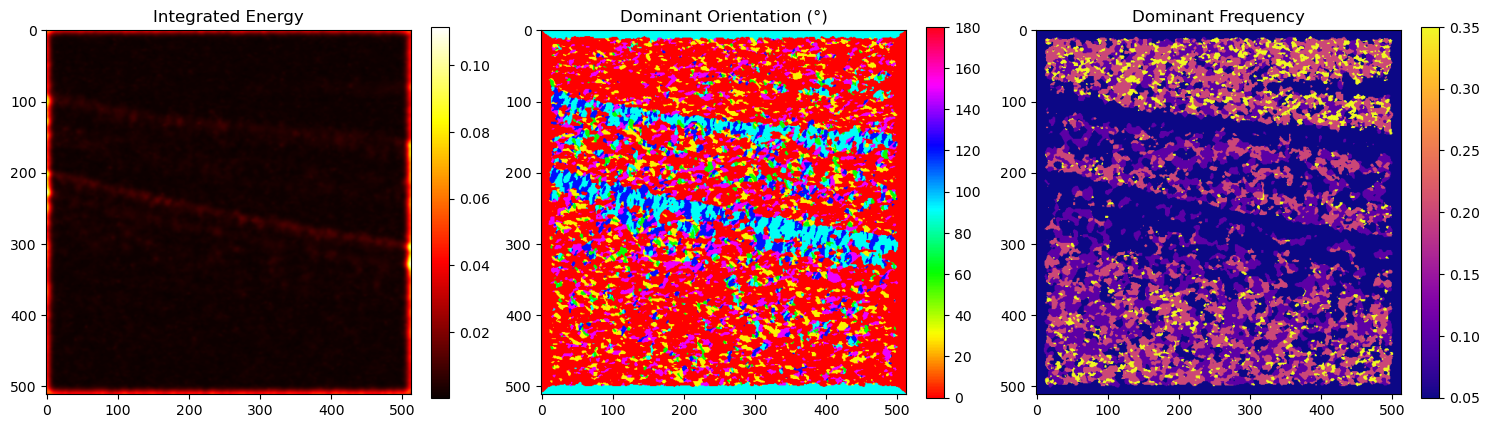

In [25]:

result_oct = pipeline.analyze(bscan, label="OCT B-Scan")

# Plot Energy and Dominant Features (Just like Lena)
# Unpack into ax1, ax2, ax3 to prevent array errors
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Energy
im0 = ax1.imshow(result_oct.energy_map, cmap='hot')
ax1.set_title('Integrated Energy')
plt.colorbar(im0, ax=ax1, fraction=0.046)

# Plot 2: Dominant Orientation
im1 = ax2.imshow(np.degrees(result_oct.dominant_orientation), cmap='hsv', vmin=0, vmax=180)
ax2.set_title('Dominant Orientation (°)')
plt.colorbar(im1, ax=ax2, fraction=0.046)

# Plot 3: Dominant Frequency
im2 = ax3.imshow(result_oct.dominant_frequency, cmap='plasma')
ax3.set_title('Dominant Frequency')
plt.colorbar(im2, ax=ax3, fraction=0.046)

plt.tight_layout()
plt.show()

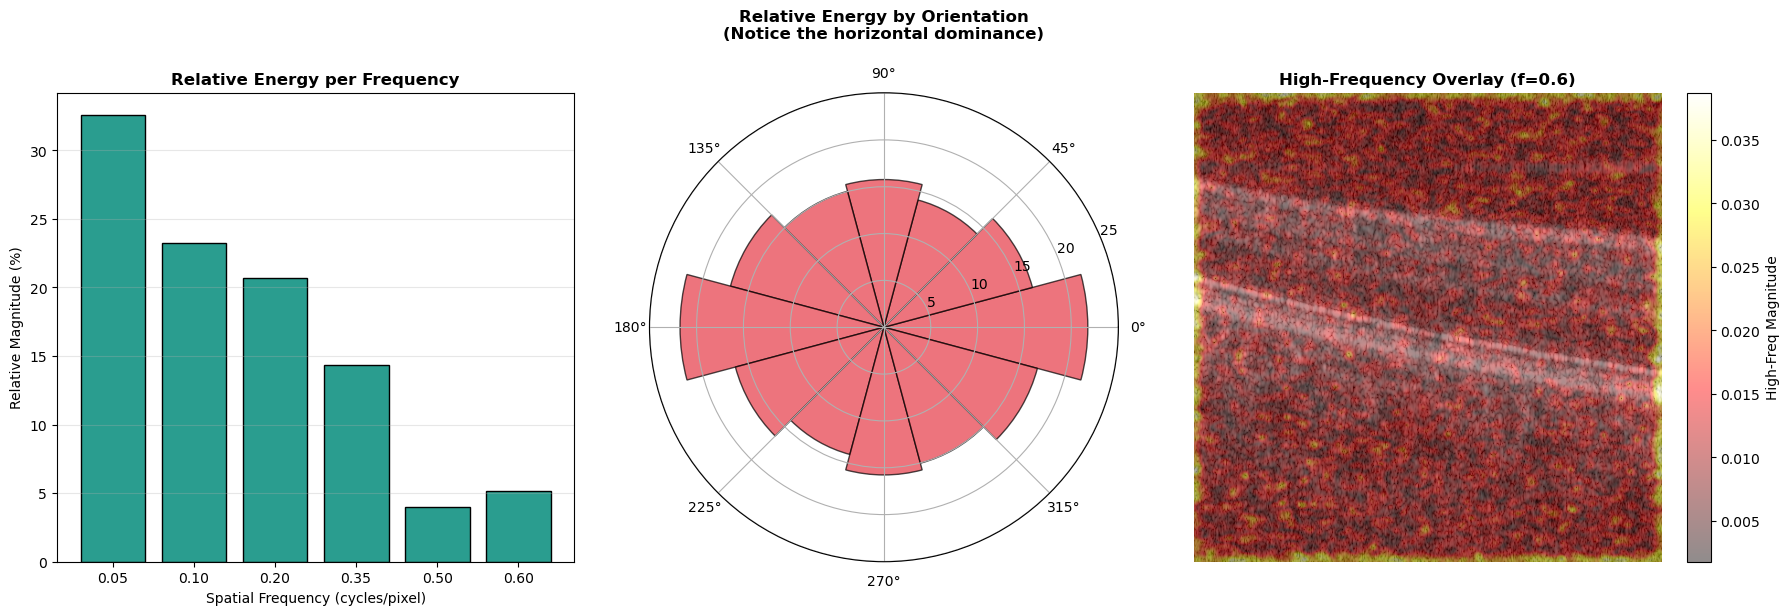

In [ ]:
# Create a figure with 3 subplots. 
# We explicitly define the second one as 'polar' for the circular histogram.
fig = plt.figure(figsize=(18, 6))

# ---------------------------------------------------------
# Plot 1: Energy by Frequency (Bar Chart)
# ---------------------------------------------------------
ax1 = fig.add_subplot(131)
# Sum the magnitude across all orientations and spatial dimensions (H, W)
raw_energy_per_freq = result_oct.responses_magnitude.sum(axis=(1, 2, 3)) 

# NORMALIZE: Convert raw sums into a percentage of the total energy
energy_per_freq = (raw_energy_per_freq / raw_energy_per_freq.sum()) * 100

freq_labels = [f"{f:.2f}" for f in result_oct.frequencies]

ax1.bar(freq_labels, energy_per_freq, color='#2a9d8f', edgecolor='black')
ax1.set_title("Relative Energy per Frequency", fontweight='bold')
ax1.set_xlabel("Spatial Frequency (cycles/pixel)")
ax1.set_ylabel("Relative Magnitude (%)") # Updated label
ax1.grid(True, axis='y', alpha=0.3)

# ---------------------------------------------------------
# Plot 2: Energy by Orientation (Polar Rose Plot)
# ---------------------------------------------------------
ax2 = fig.add_subplot(132, projection='polar')
# Sum the magnitude across all frequencies and spatial dimensions
raw_energy_per_theta = result_oct.responses_magnitude.sum(axis=(0, 2, 3))

# NORMALIZE: Convert raw sums into a percentage of the total energy
energy_per_theta = (raw_energy_per_theta / raw_energy_per_theta.sum()) * 100
thetas = result_oct.thetas

# Gabor orientations only span 0 to Pi (180 degrees). 
# To make a complete circle visually, we mirror the data to the bottom half.
theta_full = np.concatenate([thetas, thetas + np.pi])
energy_full = np.concatenate([energy_per_theta, energy_per_theta])

# Width of each bar in radians
width = np.pi / len(thetas) 
ax2.bar(theta_full, energy_full, width=width, bottom=0.0, alpha=0.7, color='#e63946', edgecolor='black')
ax2.set_title("Relative Energy by Orientation\n(Notice the horizontal dominance)", fontweight='bold', pad=20)
# Optional: Set the maximum radial limit so the scale is intuitive (e.g., max percentage + 10%)
ax2.set_rlim(0, energy_per_theta.max() * 1.15) 

# ---------------------------------------------------------
# Plot 3: Spatial Isolation (High-Frequency Overlay)
# ---------------------------------------------------------
ax3 = fig.add_subplot(133)
# Grab the highest frequency we tested (index -1) and sum across all orientations
highest_freq_idx = -1 
high_freq_mag = result_oct.responses_magnitude[highest_freq_idx].sum(axis=0) 

# Draw the original B-scan in grayscale
ax3.imshow(bscan, cmap='gray', aspect='auto', vmin=vmin, vmax=vmax)
# Overlay the high-frequency magnitude map using a hot colormap with transparency
im3 = ax3.imshow(high_freq_mag, cmap='hot', aspect='auto', alpha=0.45)

ax3.set_title(f"High-Frequency Overlay (f={result_oct.frequencies[-1]})", fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046, label='High-Freq Magnitude')

plt.tight_layout()
plt.show()

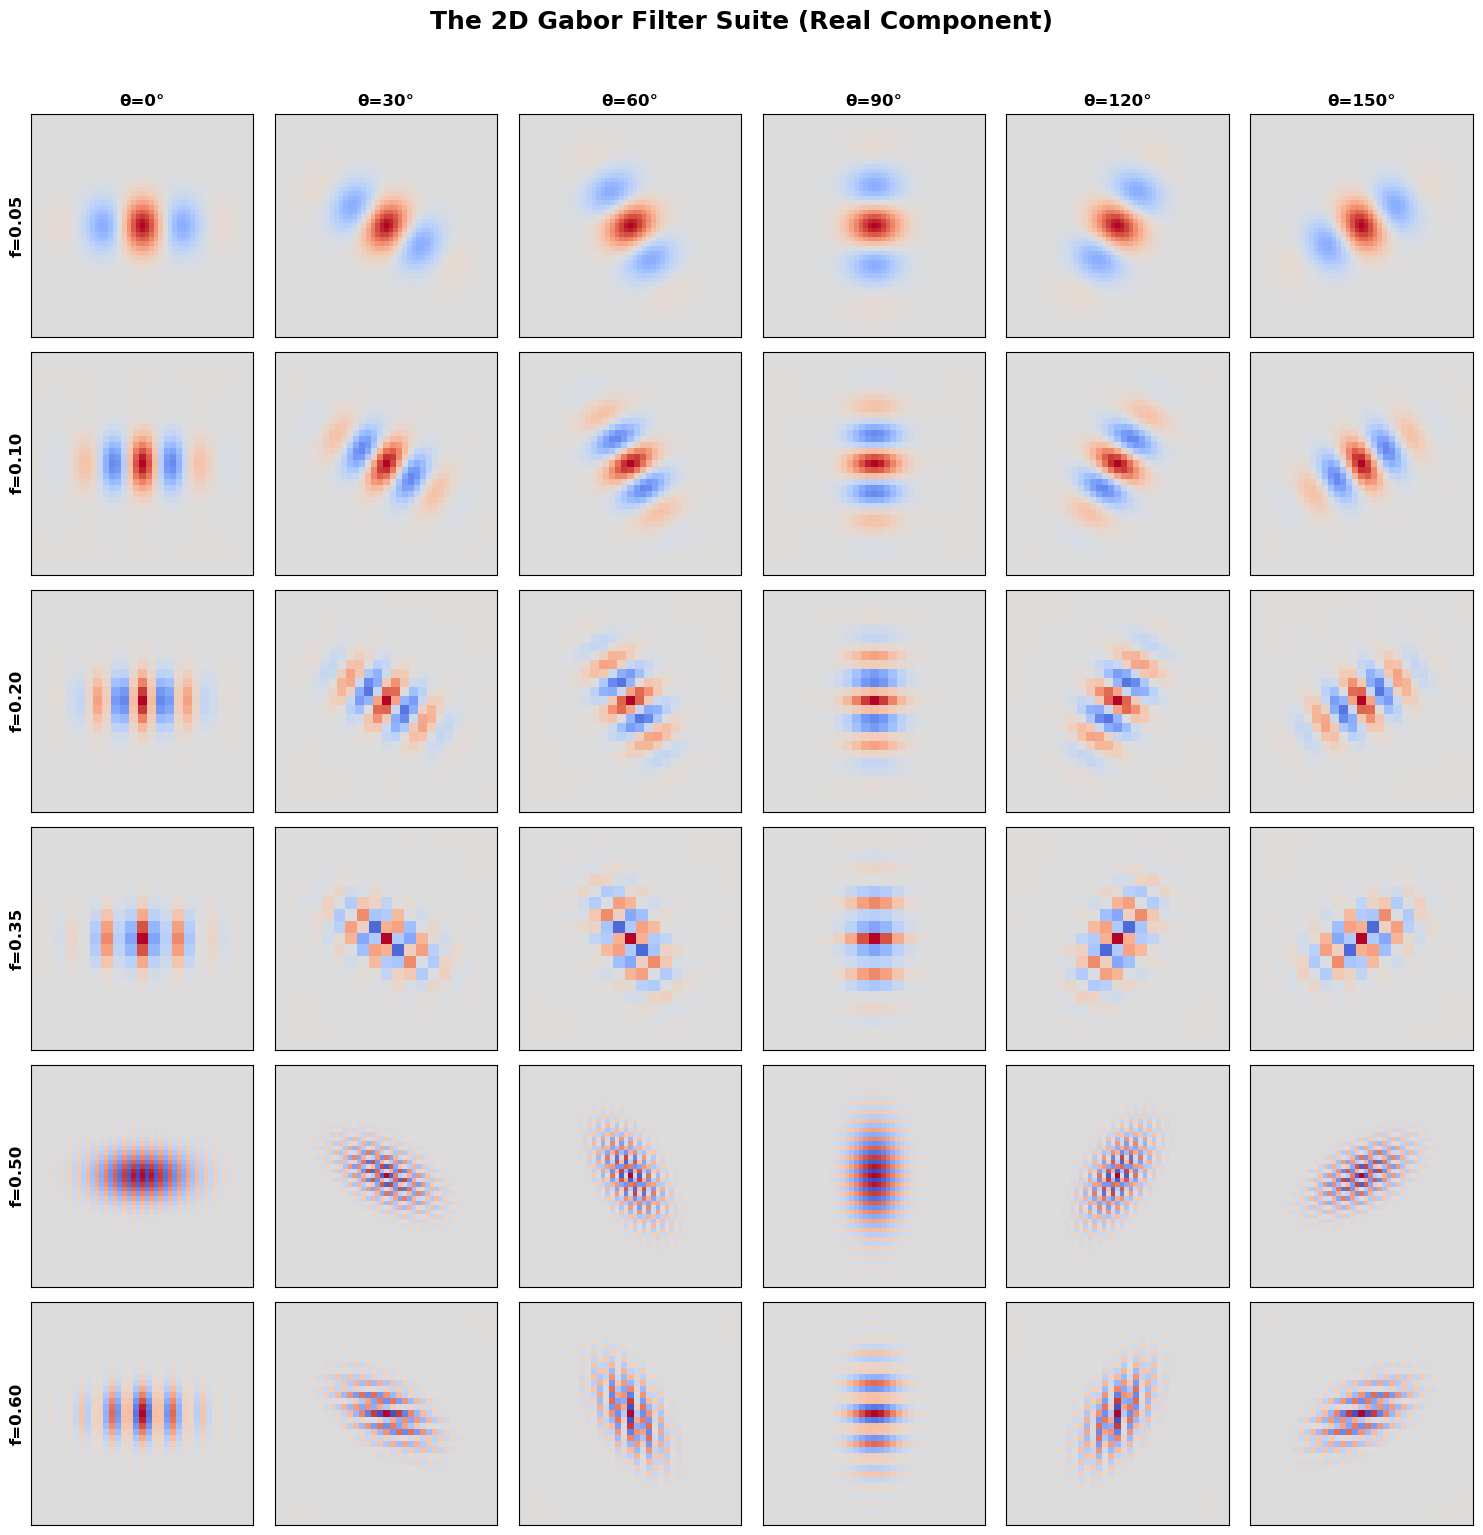

In [28]:
# We will use the params_2d object defined in Cell 5
nf = len(params_2d.frequencies)
nt = len(params_2d.thetas)

# Create a grid of subplots
fig, axes = plt.subplots(nf, nt, figsize=(nt * 2.5, nf * 2.5))

# Handle edge cases if there's only 1 frequency or 1 orientation
if nf == 1: axes = np.expand_dims(axes, 0)
if nt == 1: axes = np.expand_dims(axes, 1)

for fi, freq in enumerate(params_2d.frequencies):
    # Grab the corresponding sigmas for this frequency
    sx = params_2d.sigmas_x[fi % len(params_2d.sigmas_x)]
    sy = params_2d.sigmas_y[fi % len(params_2d.sigmas_y)]
    
    for ti, theta in enumerate(params_2d.thetas):
        # Build the mathematical kernel
        rk, ik = GaborKernel2D.build(freq, theta, sx, sy, params_2d.n_stds)
        
        ax = axes[fi, ti]
        
        # Plot the real part of the kernel
        # We use a diverging colormap to show positive and negative wave peaks
        # vmin and vmax are set symmetrically to ensure white is exactly zero
        limit = np.max(np.abs(rk))
        ax.imshow(rk, cmap='coolwarm', vmin=-limit, vmax=limit)
        
        # Add labels strictly to the outer edges to keep the grid clean
        if fi == 0:
            ax.set_title(f"θ={np.degrees(theta):.0f}°", fontsize=12, fontweight='bold')
        if ti == 0:
            ax.set_ylabel(f"f={freq:.2f}", fontsize=12, fontweight='bold')
            
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("The 2D Gabor Filter Suite (Real Component)", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()